# Session 4: Fuzzy Terms and Metric Mapping

This notebook converts raw forecast error metrics into linguistic labels for the explanation layer. 

Instead of relying on hard thresholds only, it uses fuzzy membership functions to represent gradual transitions between categories such as low, medium, and high error.

The goal is to map MAE and MPE into human-readable labels that better reflect uncertainty and overlap in model performance. 

By the end of this session, the notebook produces a working fuzzy mapping from metrics to labels like “high error” or “slight underprediction.”


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz

In [2]:
import json

with open("../src/data/metrics_all_models.json") as f:
    metrics = pd.DataFrame(json.load(f))

metrics = metrics.rename(columns={"model": "Model"})
metrics

,Model,MAE,RMSE,MAPE,MPE,DA
0,Naive,1827.63,2165.77,11.9803,5.4190,0.00
1,Seasonal Naive,1352.16,1719.28,8.9438,-0.5710,59.77
2,Linear Regression,1238.04,1505.50,7.9361,2.9084,50.58
3,ETS,1546.33,1812.99,10.0185,5.2486,66.67
4,HWES (damped),1517.14,1779.22,9.8208,5.2220,67.82
5,SARIMA,1435.00,1704.85,9.2087,4.4870,66.67
6,Prophet,1091.53,1320.09,7.0529,2.6136,65.52


### Defining the Fuzzy Universes

In [3]:
# MAE: recalibrated to real AEP daily data range (1091–1828 MW over 30-day horizon)
mae_universe  = np.arange(0, 2501, 1)
# MPE: signed bias, range −25 to +25 %
mpe_universe  = np.arange(-25, 26, 1)
# MAPE: percentage error, range 0–20 % (real-world 30-day energy benchmark)
mape_universe = np.arange(0, 21, 1)
# DA: directional accuracy, 0–100 %
da_universe   = np.arange(0, 101, 1)

### Membership Functions

In [4]:
# ── MAE membership functions (recalibrated: low=Prophet/LR, medium=stat models, high=Naive) ──
mae_low    = fuzz.trimf(mae_universe, [0,    1100, 1300])
mae_medium = fuzz.trimf(mae_universe, [1200, 1500, 1700])
mae_high   = fuzz.trimf(mae_universe, [1600, 1800, 2500])

# ── MPE membership functions (bias direction) ──
mpe_under   = fuzz.trimf(mpe_universe, [-25, -6, -0.5])
mpe_neutral = fuzz.trimf(mpe_universe, [-1.0, 0, 1.0])
mpe_over    = fuzz.trimf(mpe_universe, [0.5, 6, 25])

# ── MAPE membership functions (scale-free accuracy, benchmarked for 30-day energy forecast) ──
mape_low    = fuzz.trimf(mape_universe, [0,  5,  9])   # good performers (< ~8 %)
mape_medium = fuzz.trimf(mape_universe, [7, 10, 14])   # moderate (7–13 %)
mape_high   = fuzz.trimf(mape_universe, [9, 14, 20])   # poor (> ~11 %)

# ── DA membership functions (directional accuracy) ──
da_low      = fuzz.trimf(da_universe, [0,   0,  58])   # random / barely better than coin flip
da_medium   = fuzz.trimf(da_universe, [55, 68,  82])   # moderate directional skill
da_high     = fuzz.trimf(da_universe, [75, 90, 100])   # strong directional skill

### Plotting membership functions

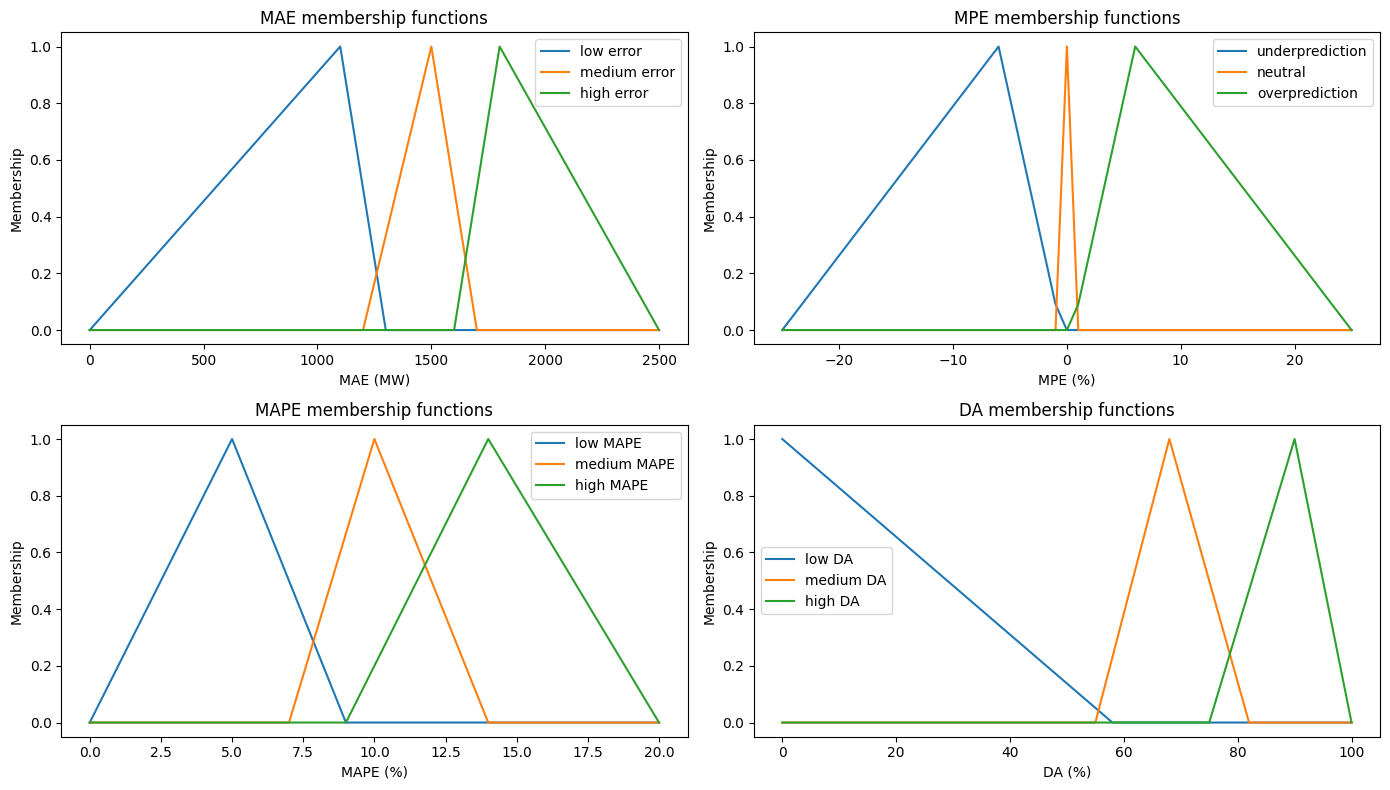

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(mae_universe, mae_low,    label="low error")
axes[0,0].plot(mae_universe, mae_medium, label="medium error")
axes[0,0].plot(mae_universe, mae_high,   label="high error")
axes[0,0].set_title("MAE membership functions"); axes[0,0].set_xlabel("MAE (MW)")
axes[0,0].set_ylabel("Membership"); axes[0,0].legend()

axes[0,1].plot(mpe_universe, mpe_under,   label="underprediction")
axes[0,1].plot(mpe_universe, mpe_neutral, label="neutral")
axes[0,1].plot(mpe_universe, mpe_over,    label="overprediction")
axes[0,1].set_title("MPE membership functions"); axes[0,1].set_xlabel("MPE (%)")
axes[0,1].set_ylabel("Membership"); axes[0,1].legend()

axes[1,0].plot(mape_universe, mape_low,    label="low MAPE")
axes[1,0].plot(mape_universe, mape_medium, label="medium MAPE")
axes[1,0].plot(mape_universe, mape_high,   label="high MAPE")
axes[1,0].set_title("MAPE membership functions"); axes[1,0].set_xlabel("MAPE (%)")
axes[1,0].set_ylabel("Membership"); axes[1,0].legend()

axes[1,1].plot(da_universe, da_low,    label="low DA")
axes[1,1].plot(da_universe, da_medium, label="medium DA")
axes[1,1].plot(da_universe, da_high,   label="high DA")
axes[1,1].set_title("DA membership functions"); axes[1,1].set_xlabel("DA (%)")
axes[1,1].set_ylabel("Membership"); axes[1,1].legend()

plt.tight_layout()
plt.show()

### Mapping Function


In [6]:
def fuzzy_label_mae(value):
    scores = {
        "low error":    fuzz.interp_membership(mae_universe, mae_low,    value),
        "medium error": fuzz.interp_membership(mae_universe, mae_medium, value),
        "high error":   fuzz.interp_membership(mae_universe, mae_high,   value),
    }
    return max(scores, key=scores.get), scores

def fuzzy_label_mpe(value):
    scores = {
        "slight underprediction": fuzz.interp_membership(mpe_universe, mpe_under,   value),
        "neutral":                fuzz.interp_membership(mpe_universe, mpe_neutral, value),
        "slight overprediction":  fuzz.interp_membership(mpe_universe, mpe_over,    value),
    }
    return max(scores, key=scores.get), scores

def fuzzy_label_mape(value):
    scores = {
        "low mape":    fuzz.interp_membership(mape_universe, mape_low,    value),
        "medium mape": fuzz.interp_membership(mape_universe, mape_medium, value),
        "high mape":   fuzz.interp_membership(mape_universe, mape_high,   value),
    }
    return max(scores, key=scores.get), scores

def fuzzy_label_da(value):
    scores = {
        "low DA":    fuzz.interp_membership(da_universe, da_low,    value),
        "medium DA": fuzz.interp_membership(da_universe, da_medium, value),
        "high DA":   fuzz.interp_membership(da_universe, da_high,   value),
    }
    return max(scores, key=scores.get), scores

def map_metrics_to_labels(row):
    mae_label,  _ = fuzzy_label_mae(row["MAE"])
    mpe_label,  _ = fuzzy_label_mpe(row["MPE"])
    mape_label, _ = fuzzy_label_mape(row["MAPE"])
    da_label,   _ = fuzzy_label_da(row["DA"])
    return pd.Series({
        "MAE_Label":  mae_label,
        "MPE_Label":  mpe_label,
        "MAPE_Label": mape_label,
        "DA_Label":   da_label,
        "Combined_Label": f"{mae_label}, {mpe_label}",
    })

### Applying to Models

In [7]:
labels  = metrics.apply(map_metrics_to_labels, axis=1)
metrics = pd.concat([metrics, labels], axis=1)
metrics.round(3)

,Model,MAE,RMSE,MAPE,MPE,DA,MAE_Label,MPE_Label,MAPE_Label,DA_Label,Combined_Label
0,Naive,1827.63,2165.77,11.980,5.419,0.00,high error,slight overprediction,high mape,low DA,"high error, slight overprediction"
1,Seasonal Naive,1352.16,1719.28,8.944,-0.571,59.77,medium error,neutral,medium mape,medium DA,"medium error, neutral"
2,Linear Regression,1238.04,1505.50,7.936,2.908,50.58,low error,slight overprediction,medium mape,low DA,"low error, slight overprediction"
3,ETS,1546.33,1812.99,10.018,5.249,66.67,medium error,slight overprediction,medium mape,medium DA,"medium error, slight overprediction"
4,HWES (damped),1517.14,1779.22,9.821,5.222,67.82,medium error,slight overprediction,medium mape,medium DA,"medium error, slight overprediction"
5,SARIMA,1435.00,1704.85,9.209,4.487,66.67,medium error,slight overprediction,medium mape,medium DA,"medium error, slight overprediction"
6,Prophet,1091.53,1320.09,7.053,2.614,65.52,low error,slight overprediction,low mape,medium DA,"low error, slight overprediction"


### Readable Output

In [8]:
for _, row in metrics.iterrows():
    print(f"{row['Model']:20s}  {row['MAE_Label']:14s}  {row['MPE_Label']:22s}  {row['MAPE_Label']:12s}  {row['DA_Label']}")

Naive                 high error      slight overprediction   high mape     low DA
Seasonal Naive        medium error    neutral                 medium mape   medium DA
Linear Regression     low error       slight overprediction   medium mape   low DA
ETS                   medium error    slight overprediction   medium mape   medium DA
HWES (damped)         medium error    slight overprediction   medium mape   medium DA
SARIMA                medium error    slight overprediction   medium mape   medium DA
Prophet               low error       slight overprediction   low mape      medium DA


In [9]:
metrics.round(3).to_csv("../src/data/session04_fuzzy_labels.csv", index=False)